### 1. K-NN model
##### This model serves as a baseline model for classification problem

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score

#### 1.1 K-NN using a simple preprocess with low dimensionality and many columns removed.
##### AKA data_no_text

In [2]:
# first use the basic no text data
data = pd.read_csv("../COMP30027_2024_asst2_data/train_dataset_no_text.csv")
test_data = pd.read_csv("../COMP30027_2024_asst2_data/test_dataset_no_text.csv")
# drop id before calculation, add back after
data = data.drop(columns='id')
test_data = test_data.drop(columns='id')

In [3]:
# split the data
X = data.drop(columns=["imdb_score_binned"])
y = data["imdb_score_binned"]

# set up scalers
mmscaler = MinMaxScaler()
ssscaler = StandardScaler()

mmscaler.fit(X)
ssscaler.fit(X)

mmX = mmscaler.transform(X)
ssX = ssscaler.transform(X)

# cross validation with different k
k_values = range(1, 51, 5)
mm_accuracies = []
ss_accuracies = []

# Loop over each k value
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    # cross validation for minmax scaled data
    scores = cross_val_score(knn, mmX, y, cv=10, scoring='accuracy')
    mm_accuracies.append(scores.mean())

    # cross validation for standard scaled data
    scores = cross_val_score(knn, ssX, y, cv=10, scoring='accuracy')
    ss_accuracies.append(scores.mean())

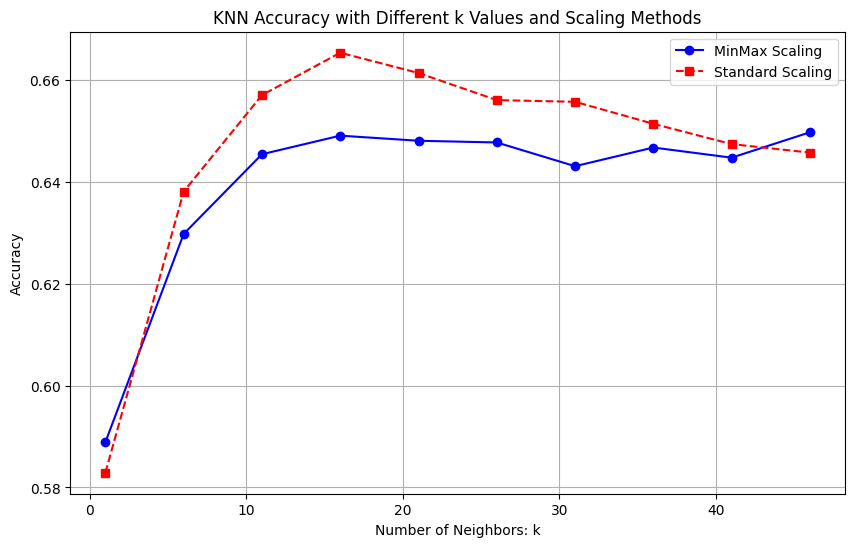

In [4]:
# plot the output
plt.figure(figsize=(10, 6))
plt.plot(k_values, mm_accuracies, marker='o', linestyle='-', color='b', label='MinMax Scaling')
plt.plot(k_values, ss_accuracies, marker='s', linestyle='--', color='r', label='Standard Scaling')
plt.xlabel('Number of Neighbors: k')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy with Different k Values and Scaling Methods')
plt.legend()
plt.grid(True)
plt.savefig("../COMP30027_2024_asst2_graph/KNN_Accuracy_No_Text")

#### Kaggle prediction on test data

In [5]:
# make prediction on test
# from above, choose the best performing and train on test data

knn_test = KNeighborsClassifier(n_neighbors=5)
test_data = ssscaler.fit_transform(test_data)

# due to the test dataset varys quite a bit in spread, scale on it's own
knn_test.fit(ssX, y)

test_pred = knn_test.predict(test_data)
ids = range(1, len(test_pred) + 1)

# save submission file
prediction = pd.DataFrame({'id': ids, 'imdb_score_binned': test_pred})
prediction.to_csv("../Kaggle_submissions/knn_no_text.csv", index=False)